# Customer Churn Prediction

## Exploratory Data Analysis (EDA)

### Project Overview

This notebook performs Exploratory Data Analysis (EDA) on the Customer Churn dataset to understand customer behavior, identify important features, visualize patterns, and prepare the dataset for machine learning classification models.

---

**Project:** Customer Churn Prediction

**Author:** Misbah Sajjad

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
data = pd.read_csv("../data/raw/Customer_Churn.csv")

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("="*60)
print("DATASET SHAPE")
print("="*60)

print(data.shape)

print("\n")

print("="*60)
print("COLUMN NAMES")
print("="*60)

print(data.columns.tolist())

print("\n")

print("="*60)
print("DATA TYPES")
print("="*60)

print(data.dtypes)

DATASET SHAPE
(7043, 21)


COLUMN NAMES
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


DATA TYPES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [4]:
data.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [5]:
missing = pd.DataFrame({
    "Missing Values": data.isnull().sum(),
    "Percentage": (
        data.isnull().sum()/len(data)
    )*100
})

missing

,Missing Values,Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [6]:
duplicates = data.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [7]:
data["TotalCharges"] = data["TotalCharges"].replace(" ", np.nan)

data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


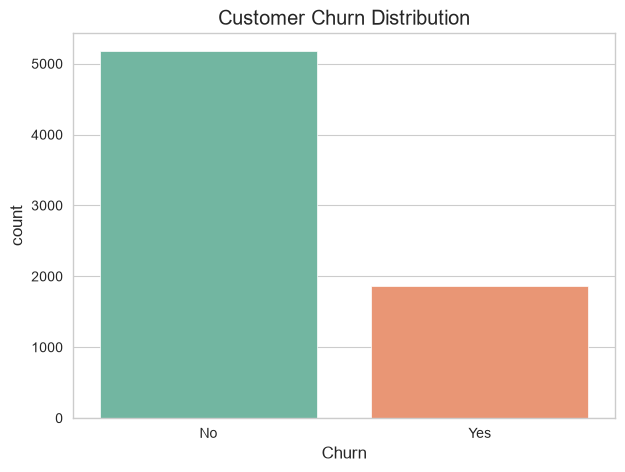

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Churn",
    data=data,
    palette="Set2"
)

plt.title("Customer Churn Distribution")

plt.show()

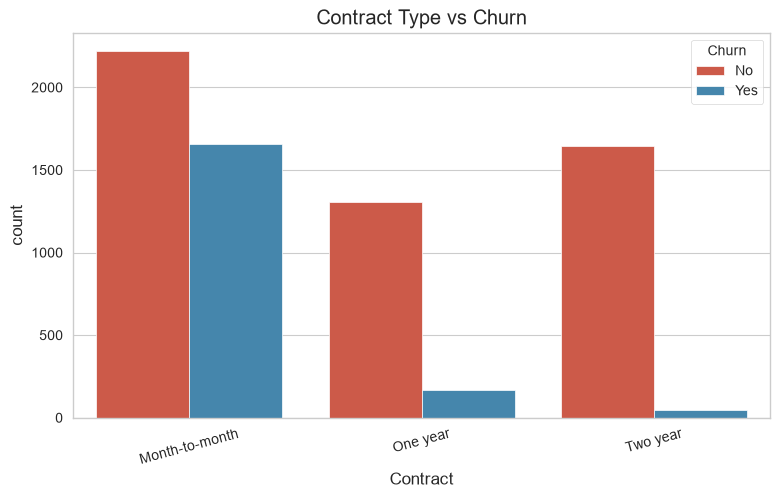

In [10]:
plt.figure(figsize=(9,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=data
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

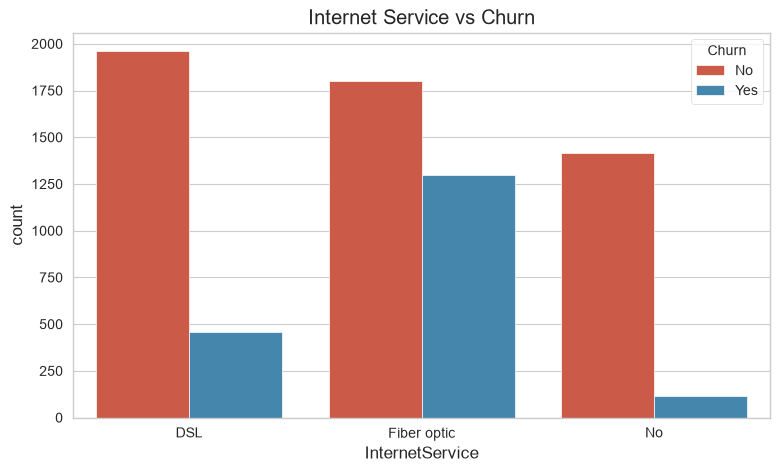

In [11]:
plt.figure(figsize=(9,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=data
)

plt.title("Internet Service vs Churn")

plt.show()

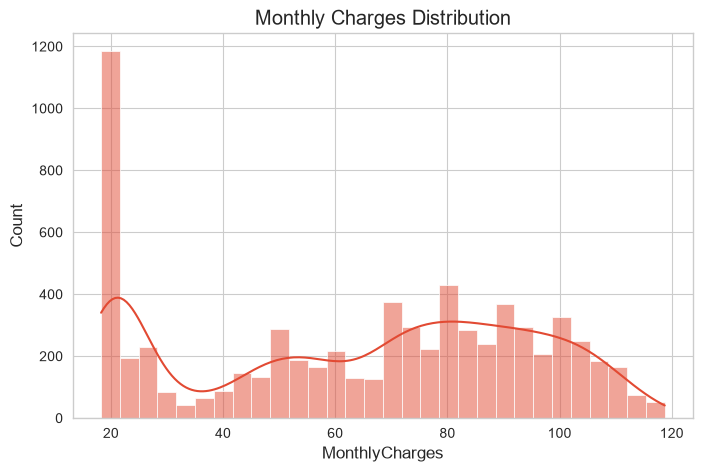

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

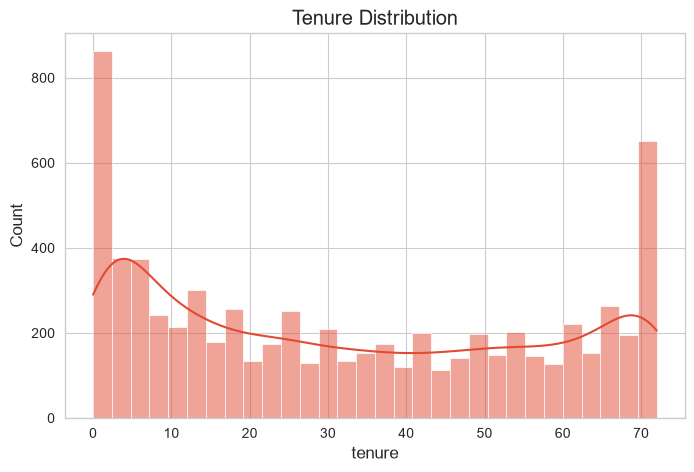

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    data["tenure"],
    bins=30,
    kde=True
)

plt.title("Tenure Distribution")

plt.show()

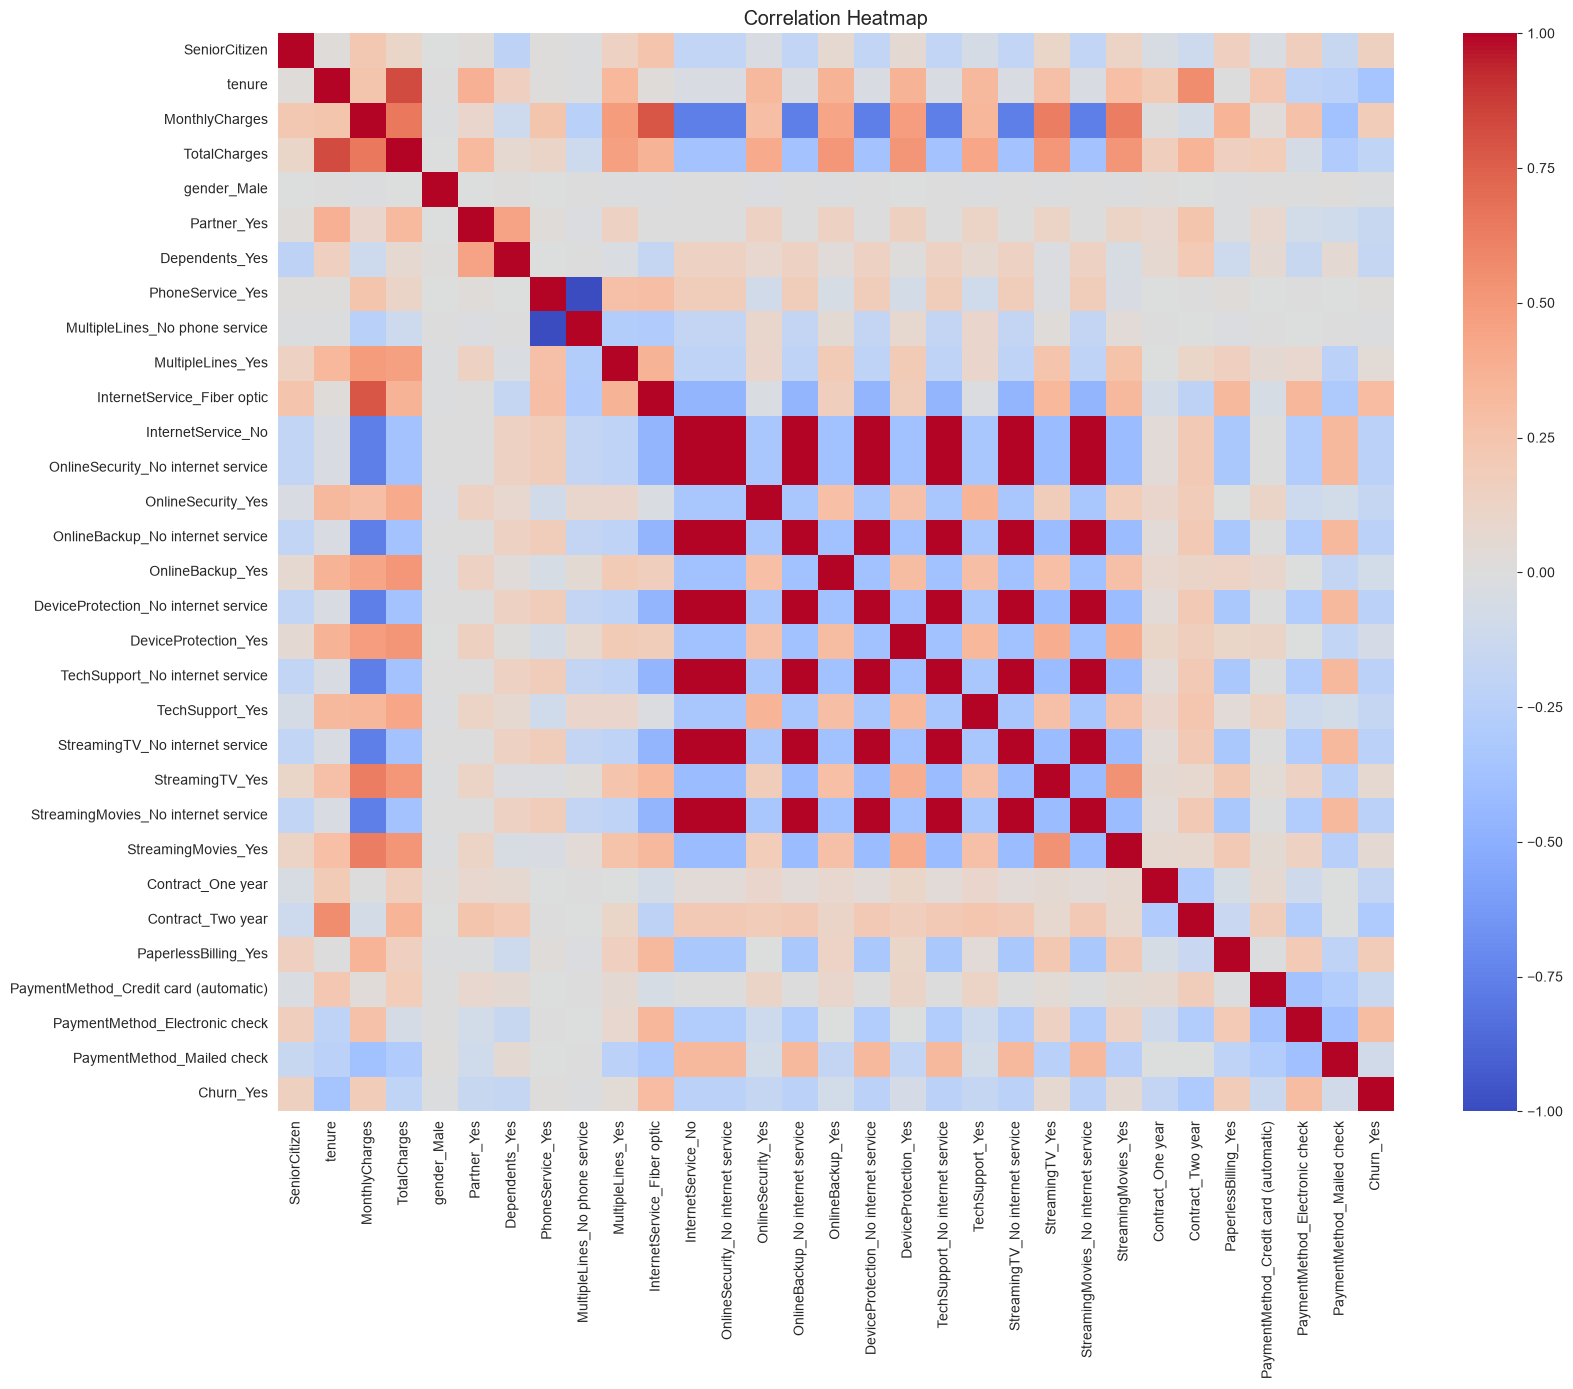

In [14]:
temp = data.copy()

temp = temp.drop(columns=["customerID"])

temp = pd.get_dummies(
    temp,
    drop_first=True
)

plt.figure(figsize=(18,14))

sns.heatmap(
    temp.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

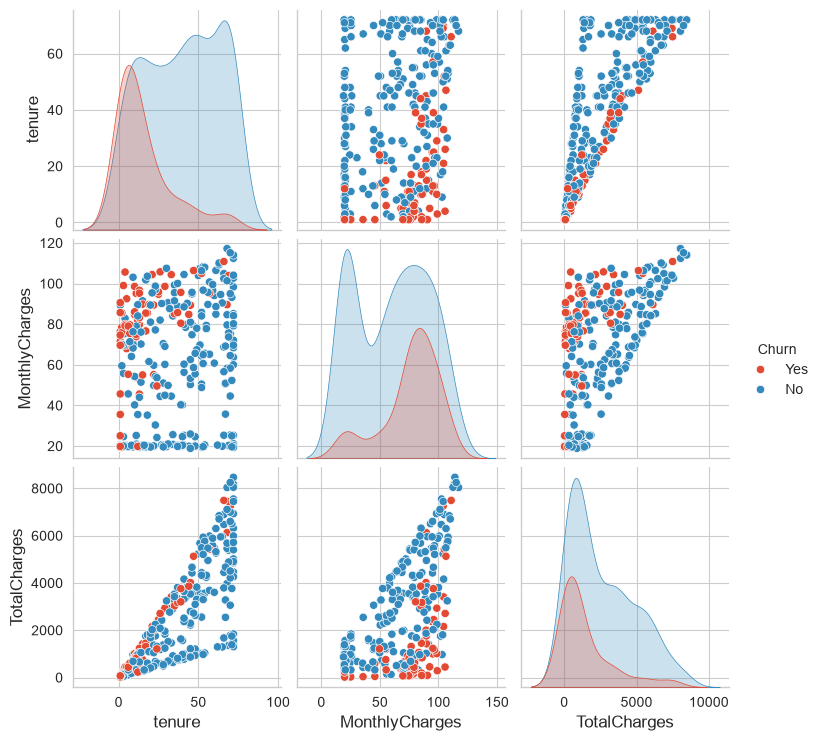

In [15]:
sample = data.sample(
    300,
    random_state=42
)

sns.pairplot(
    sample[
        [
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Churn"
        ]
    ],
    hue="Churn"
)

plt.show()

# Key Insights

- Most customers did not churn.

- Month-to-Month contracts have the highest churn rate.

- Fiber Optic customers show higher churn.

- Higher Monthly Charges increase churn probability.

- Customers with longer tenure are more loyal.

- Contract type is one of the strongest predictors.

# Conclusion

The exploratory data analysis reveals several important factors influencing customer churn.

Contract type, tenure, internet service, and monthly charges are among the most significant variables.

These findings support the development of machine learning classification models for predicting customer churn with high accuracy.